In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure reproducibility
np.random.seed(42)

df = pd.read_csv('../data/raw/data.csv')

print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

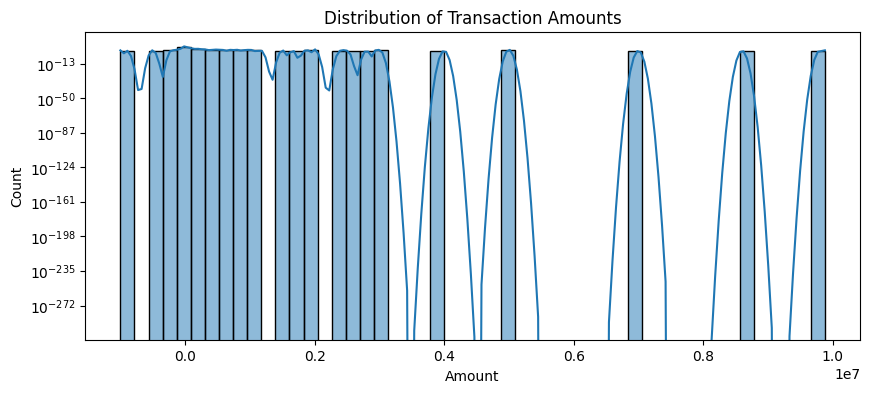

--- Value Counts for ProductCategory ---
ProductCategory
financial_services    47.463988
airtime               47.068847
utility_bill           2.007067
data_bundles           1.686145
tv                     1.336999
ticket                 0.225795
movies                 0.182936
transport              0.026134
other                  0.002091
Name: proportion, dtype: float64
--- Value Counts for ChannelId ---
ChannelId
ChannelId_3    59.516841
ChannelId_2    38.825239
ChannelId_5     1.095524
ChannelId_1     0.562397
Name: proportion, dtype: float64
--- Value Counts for PricingStrategy ---
PricingStrategy
2    83.468880
4    14.176998
1     1.951663
0     0.402459
Name: proportion, dtype: float64


In [2]:
# Distribution of transaction values
plt.figure(figsize=(10, 4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.yscale('log') # Data is typically highly skewed in transaction environments
plt.show()

# Categorical Frequency Analysis
categorical_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy']
for col in categorical_cols:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts(normalize=True) * 100)

Missing values per column:
 Series([], dtype: int64)


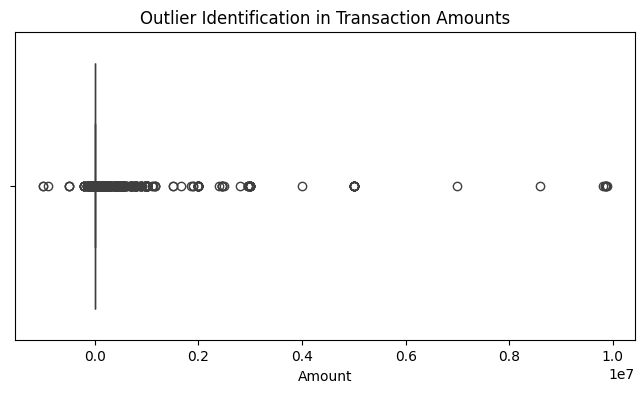

In [3]:
# Missing values check
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data[missing_data > 0])

# Outlier analysis using Box Plots
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Amount'])
plt.title('Outlier Identification in Transaction Amounts')
plt.show()

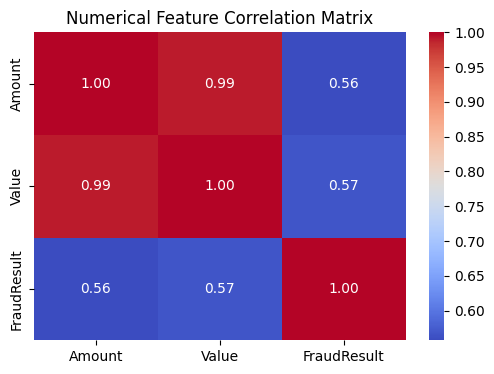

In [4]:
# Correlation between numerical values
numerical_df = df[['Amount', 'Value', 'FraudResult']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Matrix')
plt.show()

# Top 5 Strategic Insights

## 1. Severe Multicollinearity Between Amount and Value

The correlation analysis reveals a near-perfect positive correlation (0.99) between **Amount** and **Value**. This is expected because *Value* represents the absolute magnitude of a transaction, while *Amount* retains the transaction direction, with negative values indicating credits or refunds. For example, the minimum transaction amount reaches -1,000,000, reflecting reversal or refund activities.

**Implication for Modeling:**
Including both features in a linear model such as Logistic Regression could introduce significant multicollinearity, resulting in unstable coefficient estimates and reduced interpretability. A better approach would be to retain one of the variables and potentially engineer an additional feature that captures transaction direction (credit versus debit) to preserve valuable behavioral information.

---

## 2. High Value Sparsity and Extreme Outliers

The distribution of transaction values exhibits substantial skewness and dispersion. While 75% of transactions have values below approximately 2,800 UGX, the maximum transaction value exceeds 9.8 million UGX. The distribution contains a small number of extremely large transactions that are isolated from the majority of observations.

**Implication for Modeling:**
Distance-based algorithms such as K-Means clustering are highly sensitive to feature scale and extreme values. Since RFM segmentation will be used to construct the proxy target variable, applying transformations such as logarithmic scaling, RobustScaler, or StandardScaler will be essential to prevent large transactions from dominating cluster formation.

---

## 3. Strong Concentration in Essential Utility Transactions

Analysis of categorical variables shows that **financial services** and **airtime purchases** account for more than 94% of all transactions on the platform. This suggests that the platform is primarily used for recurring daily financial activities rather than discretionary purchases.

**Implication for Modeling:**
Frequent spending on essential services may provide valuable behavioral signals for alternative credit scoring. Regular airtime purchases and financial service transactions can serve as indicators of customer engagement, liquidity, and financial stability, making them useful predictors when constructing credit risk profiles.

---

## 4. Severe Class Imbalance in Fraud Records

The **FraudResult** variable has a mean of approximately 0.002, indicating that only about 0.2% of transactions are flagged as fraudulent. This demonstrates a highly imbalanced distribution. Additionally, the correlation analysis suggests a moderate positive relationship between transaction size and fraud occurrence.

**Implication for Modeling:**
Although fraud detection is not the primary objective of this project, fraud remains a strong risk signal. Customers associated with verified fraudulent activity may warrant special consideration during risk assessment. Furthermore, any future fraud-related modeling would require techniques specifically designed for imbalanced datasets.

---

## 5. High Customer Transaction Frequency Supports RFM Analysis

The dataset contains 95,662 transactions generated by approximately 3,742 unique customers, resulting in an average of more than 25 transactions per customer. This indicates that most users have a sufficiently rich transaction history.

**Implication for Modeling:**
The availability of multiple transactions per customer makes the dataset well-suited for **Recency, Frequency, and Monetary (RFM)** analysis. Rich behavioral histories enable the construction of meaningful customer segments and support the creation of a robust proxy target variable for identifying high-risk and low-risk customer groups.
